<a href="https://colab.research.google.com/github/kaushalchile05/Mlpracticle/blob/main/study_hours_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

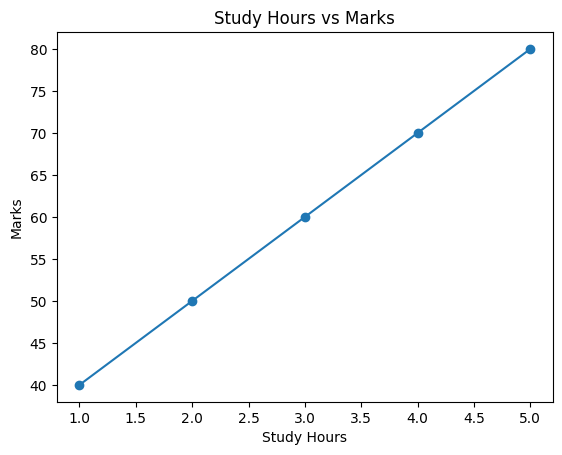

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "study_hours": [1, 2, 3, 4, 5],
    "marks": [40, 50, 60, 70, 80]
}

df = pd.DataFrame(data)

plt.plot(df["study_hours"], df["marks"], marker="o")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.show()

In [ ]:
import pandas as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

import seaborn as sns

In [ ]:
data = pd.read_csv("Housing.csv.zip")
data


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
data.shape

(21613, 21)

In [ ]:
data.isnull()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
data.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [ ]:
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
21608,False
21609,False
21610,False
21611,False


In [ ]:
data.empty

False

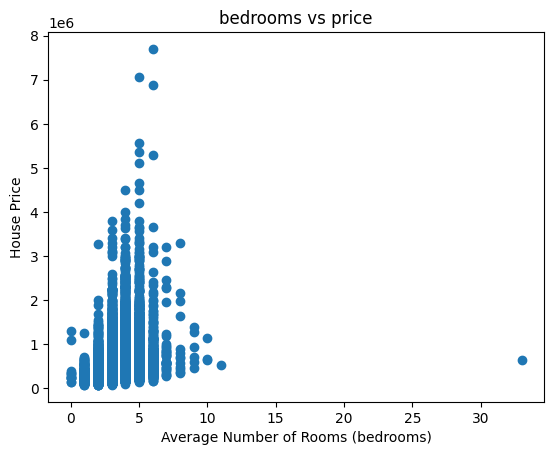

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(data["bedrooms"], data["price"])

plt.xlabel("Average Number of Rooms (bedrooms)")
plt.ylabel("House Price")

plt.title("bedrooms vs price")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = data.drop("price", axis=1)

y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training data:")
print(X_train.head())

Training data: (17290, 20)
Testing data: (4323, 20)
Training data:
               id             date  bedrooms  bathrooms  sqft_living  \
6325   5467910190  20140527T000000         3       1.75         1780   
13473  9331800580  20150310T000000         2       1.00         1000   
17614  2407000405  20150226T000000         3       1.00         1080   
16970  5466700290  20150108T000000         3       2.25         2090   
20868  3026059361  20150417T000000         2       2.50         1741   

       sqft_lot  floors  waterfront  view  condition  grade  sqft_above  \
6325      13095     1.0           0     0          4      9        1780   
13473      3700     1.0           0     0          3      6         800   
17614      7486     1.5           0     0          3      6         990   
16970      7500     1.0           0     0          4      7        1280   
20868      1439     2.0           0     0          3      8        1446   

       sqft_basement  yr_built  yr_renovated  zip

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop("price", axis=1)
y = data["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (17290, 20)
Testing data: (4323, 20)


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

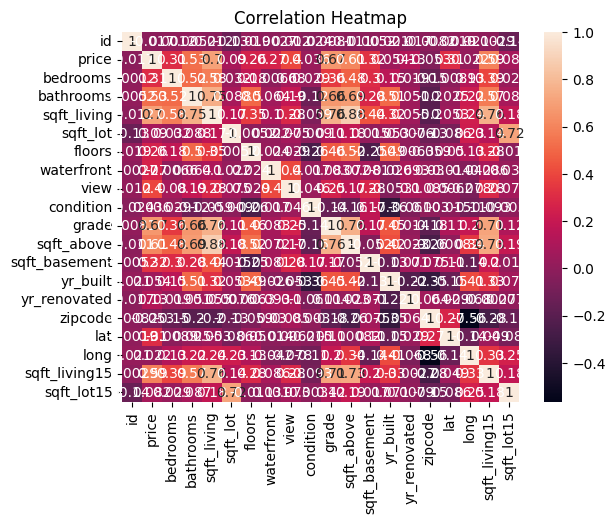

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = data.corr(numeric_only=True)

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Testing data:")
print(X_test.head())

Testing data:
               id             date  bedrooms  bathrooms  sqft_living  \
735    2591820310  20141006T000000         4       2.25         2070   
2830   7974200820  20140821T000000         5       3.00         2900   
4106   7701450110  20140815T000000         4       2.50         3770   
16218  9522300010  20150331T000000         3       3.50         4560   
19964  9510861140  20140714T000000         3       2.50         2550   

       sqft_lot  floors  waterfront  view  condition  grade  sqft_above  \
735        8893     2.0           0     0          4      8        2070   
2830       6730     1.0           0     0          5      8        1830   
4106      10893     2.0           0     2          3     11        3770   
16218     14608     2.0           0     2          3     12        4560   
19964      5376     2.0           0     0          3      9        2550   

       sqft_basement  yr_built  yr_renovated  zipcode      lat     long  \
735                0      1